<a href="https://colab.research.google.com/github/ruso404/GEN-AI-EXPS/blob/main/GENAI_week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

Generating image 2/4... ✓ Saved: sd_art_2.png


  0%|          | 0/20 [00:00<?, ?it/s]

Generating image 3/4... ✓ Saved: sd_art_3.png


  0%|          | 0/20 [00:00<?, ?it/s]

Generating image 4/4... ✓ Saved: sd_art_4.png
Generation complete!

Displaying generated art images:


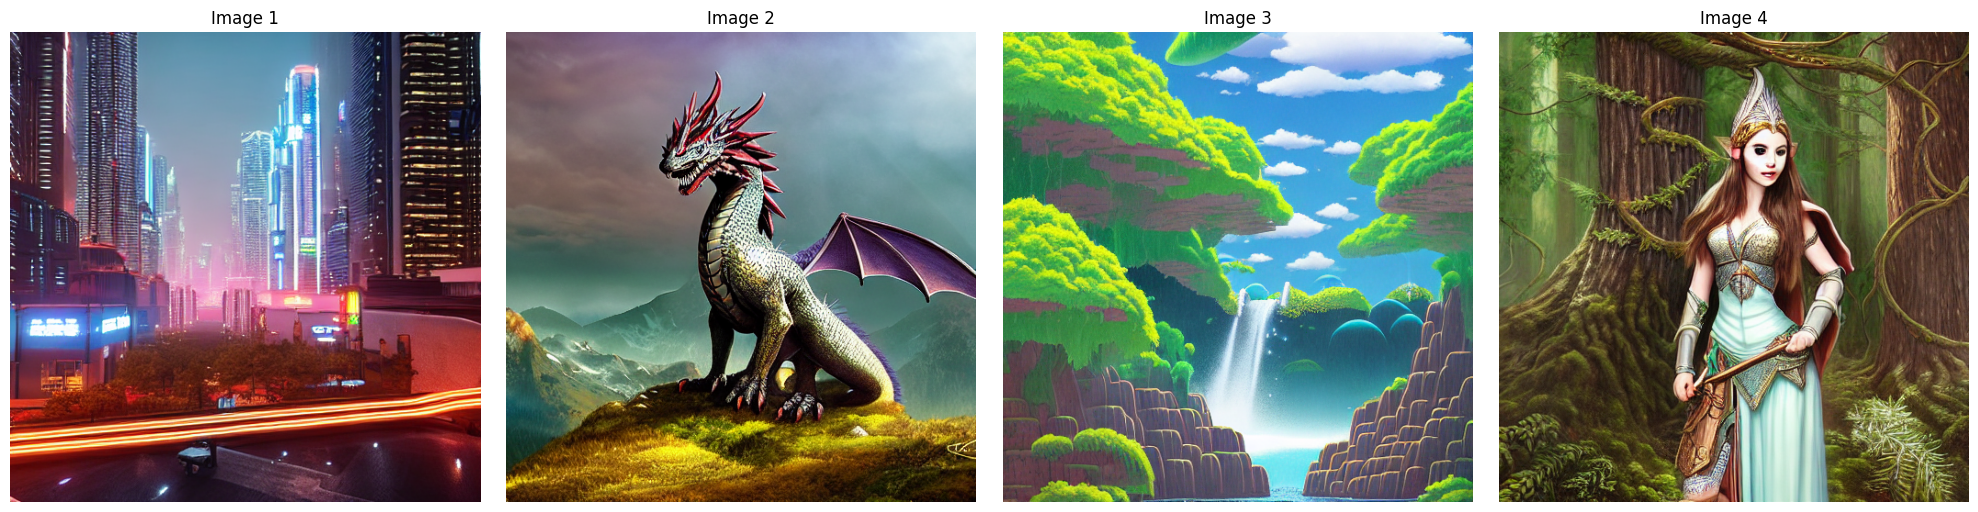

In [1]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
# Public non-gated model (no login / no auth required)
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to(device)
print("Loading Stable Diffusion 1.5...")
prompts = [
"A serene cyberpunk city at night with neon lights and flying cars, 8k cinematic",
"A majestic fantasy dragon perched on a mountain peak, epic atmosphere, digital art",
"Surreal dreamscape with floating islands and glowing waterfalls, Studio Ghibli style",
"Portrait of a beautiful elf warrior in enchanted forest, intricate details, fantasy art"
]
negative_prompt = "blurry, low quality, deformed, ugly, bad anatomy, watermark"
print("Generating image 1/4... ✓ Saved: sd_art_1.png")
images = []
for i, prompt in enumerate(prompts):
 image = pipe(prompt=prompt, negative_prompt=negative_prompt,
 num_inference_steps=20, guidance_scale=7.5,
              height=512, width=512,
 generator=torch.Generator(device).manual_seed(42+i)).images[0]
 image.save(f"sd_art_{i+1}.png")
 images.append(image)
 print(f"Generating image {i+1}/4... ✓ Saved: sd_art_{i+1}.png")
print("Generation complete!")
# === SHOW GENERATED IMAGES ===
print("\nDisplaying generated art images:")
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for i, img in enumerate(images):
 axs[i].imshow(img)
 axs[i].axis('off')
 axs[i].set_title(f"Image {i+1}")
plt.tight_layout()
plt.show()